# Mark 4C — Two-Channel vs Recall-Loss Validation Ablation

## tl;dr

Mark 4B showed that threshold calibration cannot reduce positive predicted-empty slices below 35%. This notebook therefore changes one causal factor at a time. It reuses the verified Mark 4 control and trains two bounded five-epoch arms: a source-NIfTI two-window input and a higher-positive-weight focal loss. The same split, ROIs, sampler, initialization, architecture family, seed, threshold, and validation metrics are retained.

**The test split is locked. Run this notebook with Restart Kernel and Run All.**

## Context & Methods

### Experimental contract

| Arm | Input | Loss | Training |
|---|---|---|---|
| `control` | stored broad-window PNG | Focal-Dice alpha 0.75 | reuse verified Mark 4 result |
| `two_channel` | NIfTI broad `[-160,240]` + liver `[0,200]` | Focal-Dice alpha 0.75 | 5 epochs |
| `recall_loss` | stored broad-window PNG | Focal-Dice alpha 0.90 | 5 epochs |

The two experimental arms start independently from the same frozen multi-task checkpoint. No arm starts from another arm. Selection uses the six temporary continuation targets; a higher mean patient Dice cannot compensate for a failed safety/recall target.

### Key assumptions

- Mark 3 training ROIs and Mark 4 validation ROIs are frozen.
- All metrics are calculated after mapping ROI predictions back to 256×256 coordinates.
- The threshold remains 0.50 to isolate input/loss effects.
- Five epochs are an ablation gate, not a final convergence claim.

In [1]:
from __future__ import annotations
from pathlib import Path
from IPython.display import display
import hashlib, json, random, sys, time, warnings
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
PROJECT_ROOT = Path(r'D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver')
DATASET_ROOT = Path('D:/DATA SCIENCE AND ANALYTICS/Dataset/Liver/02_staging/build_corrected_20260713_214847_v2')
MANIFEST_PATH = DATASET_ROOT/'manifests'/'slice_manifest.csv'
SOURCE_CHECKPOINT = PROJECT_ROOT/'Practice'/'multitask_liver_tumor_outputs'/'multitask_best.pth'
MARK3_DIR = PROJECT_ROOT/'mark 1'/'mark_3_outputs'
MARK4_DIR = PROJECT_ROOT/'mark 1'/'mark_4_outputs'
MARK4B_DIR = PROJECT_ROOT/'mark 1'/'mark_4b_outputs'
OUTPUT_DIR = PROJECT_ROOT/'mark 1'/'mark_4c_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

SEED=42; ROI_SIZE=256; BATCH_SIZE=16; VAL_BATCH_SIZE=24; EPOCHS=5
LR=1e-4; WEIGHT_DECAY=1e-4; POSITIVE_SAMPLE_WEIGHT=4.0; THRESHOLD=0.50
BROAD_WINDOW=(-160.0,240.0); LIVER_WINDOW=(0.0,200.0)
EXPECTED_MANIFEST_SHA256='575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889'
CONTINUATION_TARGETS={'mean_patient_dice':0.3329,'volume_104_dice':0.05,'volume_116_dice':0.01,'q1_detected_pct':35.0,'positive_predicted_empty_pct':35.0,'empty_slice_false_positive_pct':20.0}
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print('Device:',DEVICE,'| outputs:',OUTPUT_DIR)

Device: cuda | outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1\mark_4c_outputs


## Data

### 1. Verify provenance, frozen splits, ROIs, and test lock

In [2]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset
from src.framework.losses.focal_dice import FocalDiceLoss
from src.framework.models.mobilenetv2_unet import MobileNetV2UNet

def sha256_file(path):
    digest=hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda:handle.read(1024*1024),b''): digest.update(chunk)
    return digest.hexdigest()

assert sha256_file(MANIFEST_PATH)==EXPECTED_MANIFEST_SHA256
mark3=json.loads((MARK3_DIR/'mark_3_gate_result.json').read_text())
mark4=json.loads((MARK4_DIR/'mark_4_gate_result.json').read_text())
mark4b=json.loads((MARK4B_DIR/'mark_4b_gate_result.json').read_text())
assert mark3['status']=='mark_3_overfit_pass' and mark3['test_images_accessed'] is False
assert mark4['test_images_accessed'] is False and mark4b['test_images_accessed'] is False
try: VerifiedManifestDataset(MANIFEST_PATH,split='test',root_dir=DATASET_ROOT)
except PermissionError: pass
else: raise AssertionError('STOP: test split opened without authorization')

manifest=pd.read_csv(MANIFEST_PATH).sort_values(['volume_id','slice_index'])
train_rows=manifest.loc[manifest.split.eq('train')].reset_index(drop=True)
val_rows=manifest.loc[manifest.split.eq('val')].reset_index(drop=True)
train_rois=pd.read_csv(MARK3_DIR/'training_roi_manifest.csv')
val_rois=pd.read_csv(MARK4_DIR/'validation_roi_manifest.csv')
assert len(train_rows)==40667 and len(val_rows)==10685
assert len(train_rois)==104 and len(val_rois)==13
assert not train_rois.roi_empty.astype(bool).any() and not val_rois.roi_empty.astype(bool).any()
provenance={'manifest_sha256':EXPECTED_MANIFEST_SHA256,'source_checkpoint_sha256':sha256_file(SOURCE_CHECKPOINT),'seed':SEED,'epochs_per_new_arm':EPOCHS,'threshold':THRESHOLD,'test_images_accessed':False}
(OUTPUT_DIR/'mark_4c_provenance.json').write_text(json.dumps(provenance,indent=2))
print('PASS: provenance, populations, ROI manifests, prior gates, and test lock verified.')

PASS: provenance, populations, ROI manifests, prior gates, and test lock verified.


### 2. Build synchronized ROI datasets

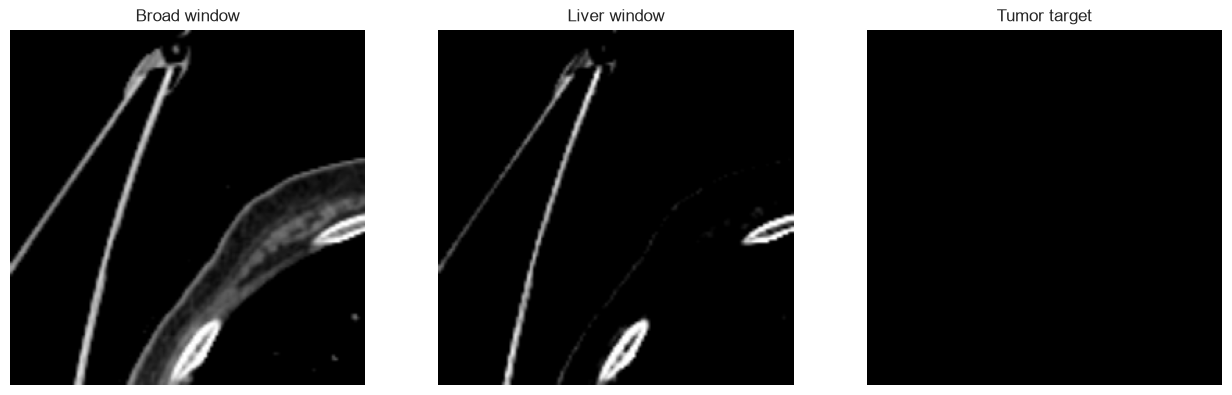

In [3]:
def resize_float(a,size=(ROI_SIZE,ROI_SIZE)):
    return np.asarray(Image.fromarray(a.astype(np.float32),mode='F').resize(size,Image.Resampling.BILINEAR),dtype=np.float32)
def resize_mask(a,size=(ROI_SIZE,ROI_SIZE)):
    return np.asarray(Image.fromarray(a.astype(np.uint8)*255).resize(size,Image.Resampling.NEAREST),dtype=np.uint8)>0
def window_hu(a,window): return np.clip((a-window[0])/(window[1]-window[0]),0,1).astype(np.float32)

class AblationDataset(Dataset):
    def __init__(self,rows,rois,mode,augment=False):
        self.rows=rows.reset_index(drop=True); self.rois=rois.set_index('volume_id'); self.mode=mode; self.augment=augment; self.nifti={}
    def __len__(self): return len(self.rows)
    def __getitem__(self,index):
        row=self.rows.iloc[index]; roi=self.rois.loc[int(row.volume_id)]
        box=np.array([roi.y0,roi.y1,roi.x0,roi.x1],dtype=np.int64); y0,y1,x0,x1=box
        if self.mode=='two_channel':
            path=str(row.source_volume_path)
            if path not in self.nifti: self.nifti[path]=nib.load(path)
            hu=np.asanyarray(self.nifti[path].dataobj[:,:,int(row.slice_index)]).astype(np.float32)
            image=np.stack([resize_float(window_hu(hu,BROAD_WINDOW)[y0:y1,x0:x1]),resize_float(window_hu(hu,LIVER_WINDOW)[y0:y1,x0:x1])])
        else:
            with Image.open(DATASET_ROOT/row.image_path) as h: broad=np.asarray(h.convert('L'),dtype=np.float32)/255.0
            image=resize_float(broad[y0:y1,x0:x1])[None]
        with Image.open(DATASET_ROOT/row.tumor_mask_path) as h: truth=np.asarray(h.convert('L'),dtype=np.uint8)>0
        mask=resize_mask(truth[y0:y1,x0:x1])[None].astype(np.float32)
        if self.augment and random.random()<0.3: image=np.flip(image,2).copy(); mask=np.flip(mask,2).copy()
        return {'image':torch.from_numpy(image),'mask':torch.from_numpy(mask),'sample_id':row.sample_id,'volume_id':int(row.volume_id),'slice_index':int(row.slice_index),'box':torch.from_numpy(box)}

datasets={mode:{'train':AblationDataset(train_rows,train_rois,mode,True),'val':AblationDataset(val_rows,val_rois,mode,False)} for mode in ['broad','two_channel']}
preview=datasets['two_channel']['train'][10000]
fig,ax=plt.subplots(1,3,figsize=(13,4)); ax[0].imshow(preview['image'][0],cmap='gray'); ax[0].set_title('Broad window'); ax[1].imshow(preview['image'][1],cmap='gray'); ax[1].set_title('Liver window'); ax[2].imshow(preview['mask'][0],cmap='gray'); ax[2].set_title('Tumor target')
for a in ax:a.axis('off')
fig.tight_layout(); fig.savefig(OUTPUT_DIR/'two_channel_tensor_audit.png',dpi=160,bbox_inches='tight'); plt.show()

### 3. Define fair initialization, sampling, evaluation, and gate logic

In [4]:
source_state=torch.load(SOURCE_CHECKPOINT,map_location='cpu',weights_only=False)['model_state']
volume_counts=train_rows.volume_id.value_counts()
sample_weights=train_rows.volume_id.map(lambda v:1/volume_counts.loc[v]).to_numpy(float)*np.where(train_rows.tumor_pixels.to_numpy()>0,POSITIVE_SAMPLE_WEIGHT,1.0)

def make_model(channels):
    model=MobileNetV2UNet(in_channels=channels,out_channels=1,pretrained=False); state=model.state_dict()
    for key,value in source_state.items():
        if key in state and state[key].shape==value.shape: state[key]=value.clone()
    if channels==2:
        state['enc_0.0.weight']=source_state['enc_0.0.weight'].repeat(1,2,1,1)/2
    state['final.weight']=source_state['final.weight'][1:2].clone(); state['final.bias']=source_state['final.bias'][1:2].clone()
    model.load_state_dict(state,strict=True); return model.to(DEVICE)

def make_loaders(mode):
    gen=torch.Generator().manual_seed(SEED)
    sampler=WeightedRandomSampler(torch.as_tensor(sample_weights,dtype=torch.double),len(train_rows),replacement=True,generator=gen)
    return (DataLoader(datasets[mode]['train'],batch_size=BATCH_SIZE,sampler=sampler,num_workers=0,pin_memory=torch.cuda.is_available()),DataLoader(datasets[mode]['val'],batch_size=VAL_BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=torch.cuda.is_available()))

def probability_to_full(prob,box):
    y0,y1,x0,x1=map(int,box); resized=resize_float(prob,(x1-x0,y1-y0)); full=np.zeros((256,256),np.float32); full[y0:y1,x0:x1]=resized; return full

val_lookup=val_rows.set_index('sample_id'); q1_limit=val_rows.loc[val_rows.tumor_pixels.gt(0),'tumor_pixels'].quantile(.25)
def evaluate(model,loader,loss_fn):
    model.eval(); acc={}; slices=[]; total_loss=0
    with torch.inference_mode():
        for batch in loader:
            images=batch['image'].to(DEVICE); masks=batch['mask'].to(DEVICE); logits=model(images); total_loss+=float(loss_fn(logits,masks))*len(images)
            probs=torch.sigmoid(logits).cpu().numpy()[:,0]
            for i,sid in enumerate(batch['sample_id']):
                row=val_lookup.loc[sid]; truth=np.asarray(Image.open(DATASET_ROOT/row.tumor_mask_path).convert('L'),dtype=np.uint8)>0
                pred=probability_to_full(probs[i],batch['box'][i].numpy())>=THRESHOLD; vid=int(row.volume_id)
                item=acc.setdefault(vid,{'inter':0,'pred':0,'truth':0}); item['inter']+=int((pred&truth).sum()); item['pred']+=int(pred.sum()); item['truth']+=int(truth.sum())
                slices.append({'sample_id':sid,'volume_id':vid,'slice_index':int(row.slice_index),'truth_pixels':int(truth.sum()),'predicted_pixels':int(pred.sum()),'detected':bool((pred&truth).any()),'q1':bool(0<int(truth.sum())<=q1_limit)})
    patients=pd.DataFrame([{'volume_id':vid,'dice':(2*a['inter']+1e-6)/(a['pred']+a['truth']+1e-6)} for vid,a in acc.items()]); sf=pd.DataFrame(slices); positive=sf.truth_pixels.gt(0); empty=~positive; q1=sf.q1
    metrics={'validation_loss':total_loss/len(val_rows),'mean_patient_dice':patients.dice.mean(),'volume_104_dice':patients.set_index('volume_id').loc[104,'dice'],'volume_116_dice':patients.set_index('volume_id').loc[116,'dice'],'q1_detected_pct':100*sf.loc[q1,'detected'].mean(),'positive_predicted_empty_pct':100*sf.loc[positive,'predicted_pixels'].eq(0).mean(),'empty_slice_false_positive_pct':100*sf.loc[empty,'predicted_pixels'].gt(0).mean()}
    return metrics,patients,sf

def target_passes(row):
    return {k:(row[k]<=v if k in ['positive_predicted_empty_pct','empty_slice_false_positive_pct'] else row[k]>=v) for k,v in CONTINUATION_TARGETS.items()}

## Results

### 4. Train the two bounded experimental arms

In [5]:
ARMS={'two_channel':{'mode':'two_channel','channels':2,'alpha':.75},'recall_loss':{'mode':'broad','channels':1,'alpha':.90}}
all_history=[]; best_artifacts={}
for arm,cfg in ARMS.items():
    print(f'\n=== {arm} ==='); random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    model=make_model(cfg['channels']); train_loader,val_loader=make_loaders(cfg['mode'])
    loss_fn=FocalDiceLoss(focal_alpha=cfg['alpha'],focal_gamma=2,focal_weight=.5,dice_weight=.5)
    opt=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY); scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=EPOCHS,eta_min=1e-6)
    best_score=-1
    for epoch in range(1,EPOCHS+1):
        model.train(); [m.eval() for m in model.modules() if isinstance(m,nn.BatchNorm2d)]; train_loss=0; started=time.perf_counter()
        for batch in train_loader:
            x=batch['image'].to(DEVICE); y=batch['mask'].to(DEVICE); opt.zero_grad(set_to_none=True); loss=loss_fn(model(x),y)
            if not torch.isfinite(loss): raise FloatingPointError(f'{arm}: non-finite loss')
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step(); train_loss+=float(loss)*len(x)
        metrics,patients,slices=evaluate(model,val_loader,loss_fn); scheduler.step()
        record={'arm':arm,'epoch':epoch,'train_loss':train_loss/len(train_rows),'minutes':(time.perf_counter()-started)/60,**metrics}; all_history.append(record); print(record)
        if metrics['mean_patient_dice']>best_score:
            best_score=metrics['mean_patient_dice']; best_artifacts[arm]=(record,patients.copy(),slices.copy())
            torch.save({'arm':arm,'epoch':epoch,'model_state':{k:v.detach().cpu() for k,v in model.state_dict().items()},'manifest_sha256':EXPECTED_MANIFEST_SHA256,'source_checkpoint_sha256':provenance['source_checkpoint_sha256'],'config':cfg},OUTPUT_DIR/f'{arm}_best.pth')
    pd.DataFrame(all_history).to_csv(OUTPUT_DIR/'mark_4c_history.csv',index=False)
    if torch.cuda.is_available(): torch.cuda.empty_cache()


=== two_channel ===
{'arm': 'two_channel', 'epoch': 1, 'train_loss': 0.2608826444306695, 'minutes': 13.665245439999854, 'validation_loss': 0.07899784586476453, 'mean_patient_dice': np.float64(0.3076923080594979), 'volume_104_dice': np.float64(1.4486035461604966e-11), 'volume_116_dice': np.float64(6.546087730624914e-12), 'q1_detected_pct': np.float64(0.0), 'positive_predicted_empty_pct': np.float64(100.0), 'empty_slice_false_positive_pct': np.float64(0.0)}
{'arm': 'two_channel', 'epoch': 2, 'train_loss': 0.25300623433451047, 'minutes': 13.379020425000151, 'validation_loss': 0.20224453039296497, 'mean_patient_dice': np.float64(0.009494490503971149), 'volume_104_dice': np.float64(1.4486035461604966e-11), 'volume_116_dice': np.float64(0.0048190932793051155), 'q1_detected_pct': np.float64(3.041825095057034), 'positive_predicted_empty_pct': np.float64(42.80230326295585), 'empty_slice_false_positive_pct': np.float64(13.750907393964534)}
{'arm': 'two_channel', 'epoch': 3, 'train_loss': 0.2190

C:\Users\alanm\AppData\Local\Temp\ipykernel_20672\2748177930.py:25: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  return {'image':torch.from_numpy(image),'mask':torch.from_numpy(mask),'sample_id':row.sample_id,'volume_id':int(row.volume_id),'slice_index':int(row.slice_index),'box':torch.from_numpy(box)}


{'arm': 'recall_loss', 'epoch': 1, 'train_loss': 0.11992397154940969, 'minutes': 262.1142593316666, 'validation_loss': 0.07488365485448395, 'mean_patient_dice': np.float64(0.23684743236767952), 'volume_104_dice': np.float64(0.18066116728672504), 'volume_116_dice': np.float64(0.006673455408850505), 'q1_detected_pct': np.float64(43.72623574144487), 'positive_predicted_empty_pct': np.float64(29.270633397312864), 'empty_slice_false_positive_pct': np.float64(5.527325521103391)}
{'arm': 'recall_loss', 'epoch': 2, 'train_loss': 0.09200903006740946, 'minutes': 8.884223499999885, 'validation_loss': 0.06669596869866314, 'mean_patient_dice': np.float64(0.2570601932229069), 'volume_104_dice': np.float64(0.004650371476710566), 'volume_116_dice': np.float64(0.005317182936995809), 'q1_detected_pct': np.float64(34.60076045627377), 'positive_predicted_empty_pct': np.float64(38.1957773512476), 'empty_slice_false_positive_pct': np.float64(2.8621798195582286)}
{'arm': 'recall_loss', 'epoch': 3, 'train_los

### 5. Reconcile against the verified control and select by the complete gate

In [6]:
control_history=pd.read_csv(MARK4_DIR/'mark_4_history.csv'); control=control_history.loc[control_history.mean_patient_dice.idxmax()].to_dict()
rows=[{'arm':'control','epoch':int(control['epoch']),**{k:float(control[k]) for k in ['validation_loss',*CONTINUATION_TARGETS]}}]
for arm,(record,patients,slices) in best_artifacts.items():
    rows.append({'arm':arm,'epoch':record['epoch'],**{k:record[k] for k in ['validation_loss',*CONTINUATION_TARGETS]}})
comparison=pd.DataFrame(rows)
for i,row in comparison.iterrows():
    passes=target_passes(row); comparison.loc[i,'targets_passed']=sum(passes.values()); comparison.loc[i,'all_targets_passed']=all(passes.values())
comparison.to_csv(OUTPUT_DIR/'arm_comparison.csv',index=False); display(comparison)
eligible=comparison.loc[comparison.all_targets_passed.astype(bool)]
winner=None if eligible.empty else eligible.sort_values('mean_patient_dice',ascending=False).iloc[0].arm
print('Selected arm:',winner or 'NONE — no arm passed the complete continuation gate')

,arm,epoch,validation_loss,mean_patient_dice,volume_104_dice,volume_116_dice,q1_detected_pct,positive_predicted_empty_pct,empty_slice_false_positive_pct,targets_passed,all_targets_passed
0,control,5,0.060651,0.363866,6.718718e-02,1.078028e-02,42.585551,36.852207,3.422172,5.0,False
1,two_channel,1,0.078998,0.307692,1.448604e-11,6.546088e-12,0.000000,100.000000,0.000000,1.0,False
2,recall_loss,4,0.072988,0.259561,1.038216e-01,8.532865e-04,47.908745,30.134357,4.842891,4.0,False


Selected arm: NONE — no arm passed the complete continuation gate


### 6. Visualize learning, gate trade-offs, and patient effects

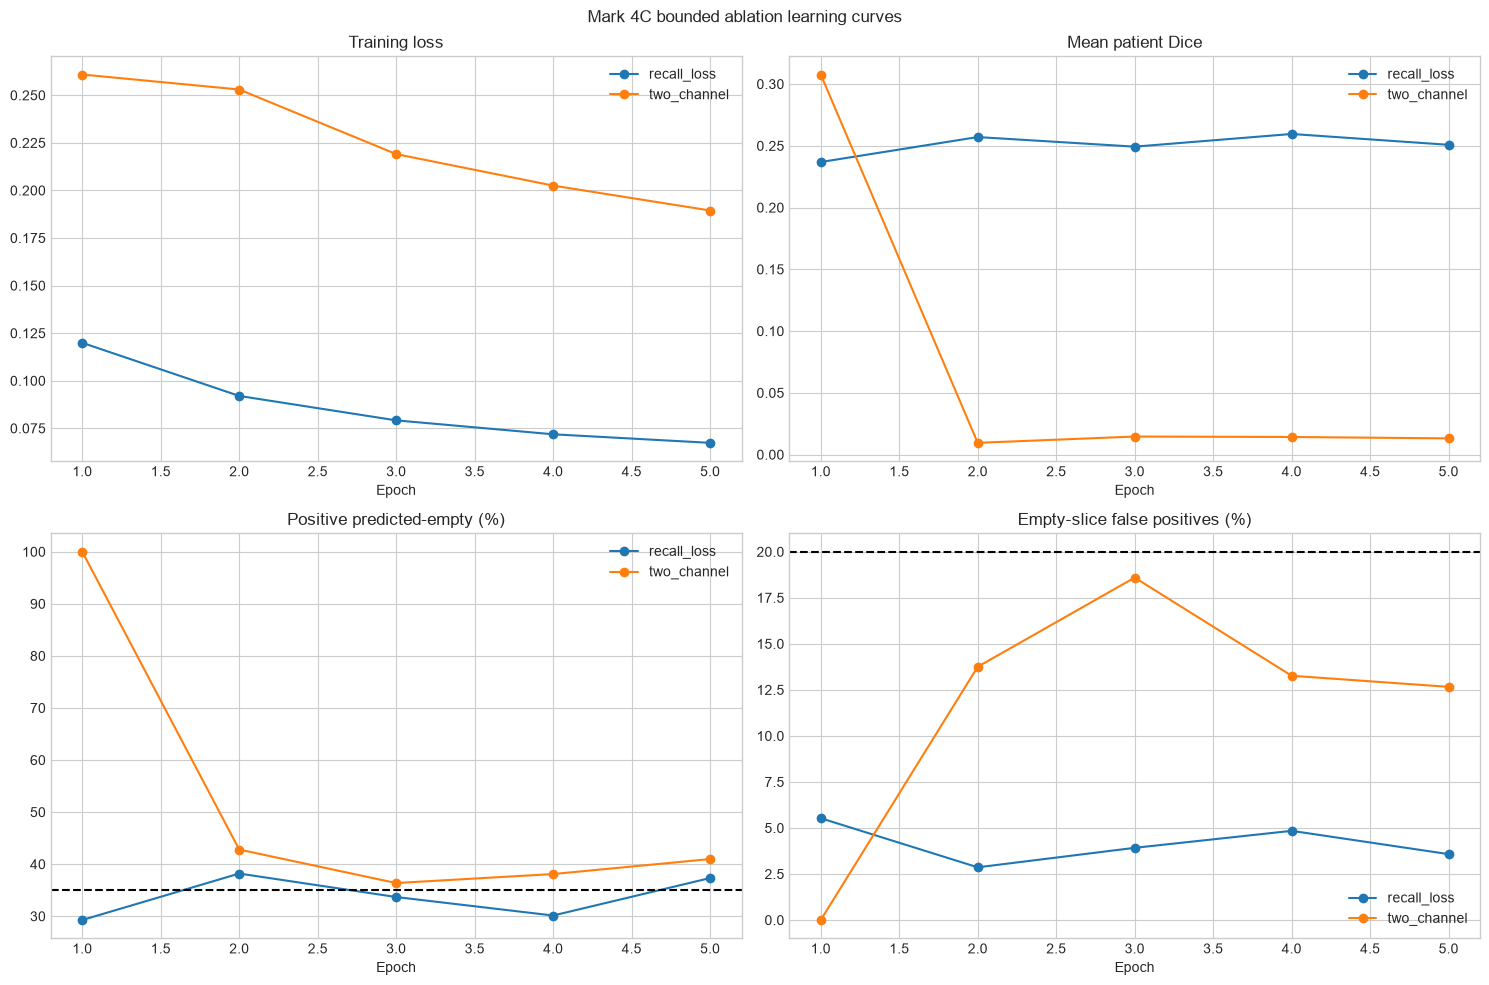

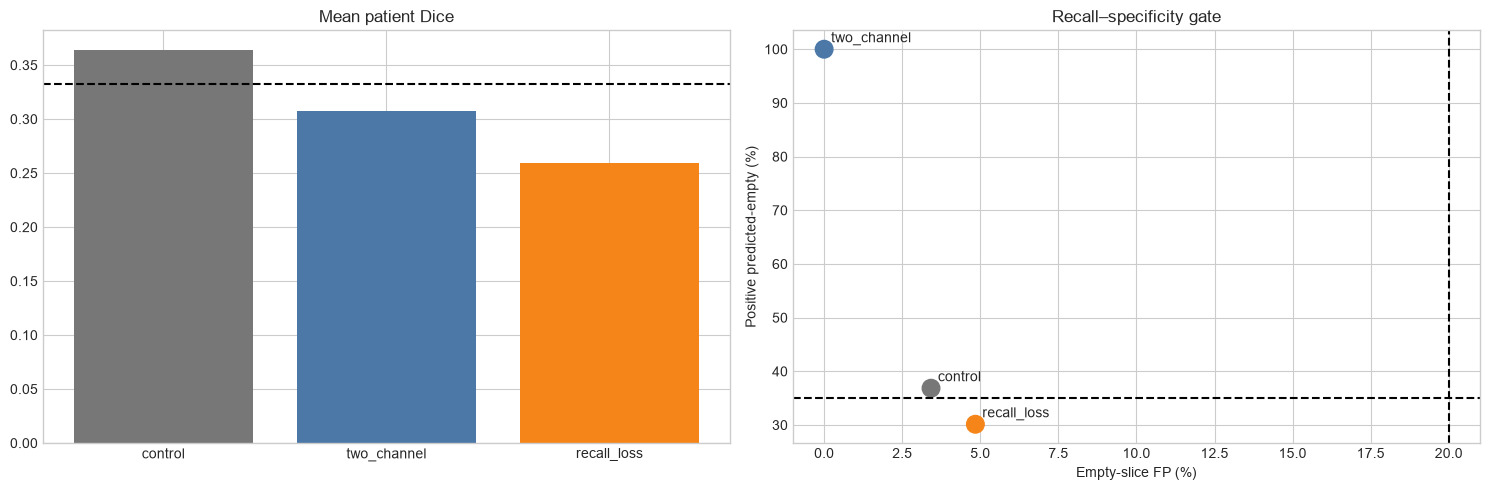

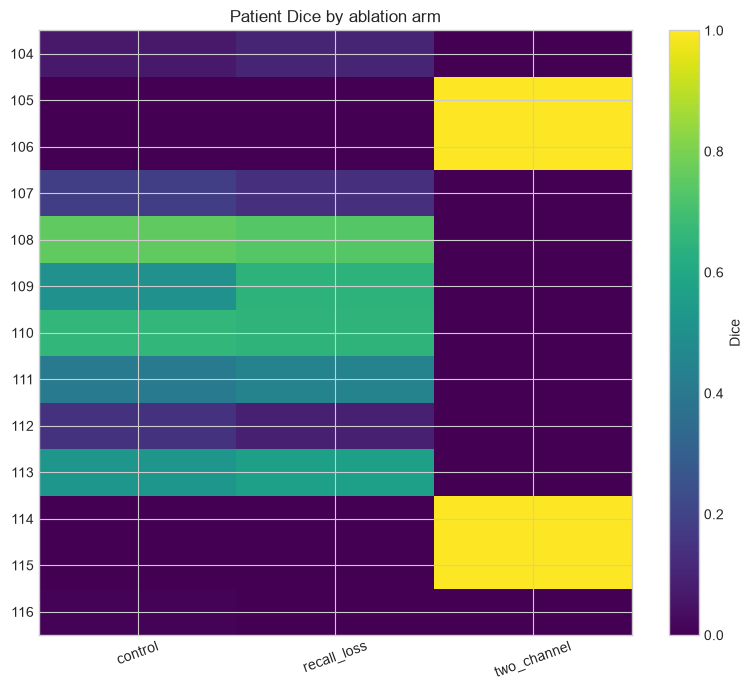

In [7]:
history=pd.DataFrame(all_history); fig,ax=plt.subplots(2,2,figsize=(15,10))
for arm,g in history.groupby('arm'):
    ax[0,0].plot(g.epoch,g.train_loss,marker='o',label=arm); ax[0,1].plot(g.epoch,g.mean_patient_dice,marker='o',label=arm); ax[1,0].plot(g.epoch,g.positive_predicted_empty_pct,marker='o',label=arm); ax[1,1].plot(g.epoch,g.empty_slice_false_positive_pct,marker='o',label=arm)
ax[0,0].set_title('Training loss'); ax[0,1].set_title('Mean patient Dice'); ax[1,0].set_title('Positive predicted-empty (%)'); ax[1,0].axhline(35,ls='--',c='black'); ax[1,1].set_title('Empty-slice false positives (%)'); ax[1,1].axhline(20,ls='--',c='black')
for a in ax.ravel(): a.legend(); a.set_xlabel('Epoch')
fig.suptitle('Mark 4C bounded ablation learning curves'); fig.tight_layout(); fig.savefig(OUTPUT_DIR/'ablation_learning_dashboard.png',dpi=170,bbox_inches='tight'); plt.show()

fig,ax=plt.subplots(1,2,figsize=(15,5)); colors=['#777','#4C78A8','#F58518']
ax[0].bar(comparison.arm,comparison.mean_patient_dice,color=colors); ax[0].axhline(CONTINUATION_TARGETS['mean_patient_dice'],ls='--',c='black'); ax[0].set_title('Mean patient Dice')
ax[1].scatter(comparison.empty_slice_false_positive_pct,comparison.positive_predicted_empty_pct,s=160,c=colors)
for _,r in comparison.iterrows(): ax[1].annotate(r.arm,(r.empty_slice_false_positive_pct,r.positive_predicted_empty_pct),xytext=(5,5),textcoords='offset points')
ax[1].axhline(35,ls='--',c='black'); ax[1].axvline(20,ls='--',c='black'); ax[1].set_xlabel('Empty-slice FP (%)'); ax[1].set_ylabel('Positive predicted-empty (%)'); ax[1].set_title('Recall–specificity gate')
fig.tight_layout(); fig.savefig(OUTPUT_DIR/'control_vs_ablation.png',dpi=170,bbox_inches='tight'); plt.show()

patient_frames=[]
control_patients=pd.read_csv(MARK4_DIR/'best_validation_patient_metrics.csv').rename(columns={'micro_dice':'dice'})
assert {'volume_id','dice'}.issubset(control_patients.columns), control_patients.columns.tolist()
control_patients['arm']='control'; patient_frames.append(control_patients[['volume_id','dice','arm']])
for arm,(_,patients,_) in best_artifacts.items(): patients=patients.copy(); patients['arm']=arm; patient_frames.append(patients)
patient_table=pd.concat(patient_frames); patient_table.to_csv(OUTPUT_DIR/'arm_patient_metrics.csv',index=False)
pivot=patient_table.pivot(index='volume_id',columns='arm',values='dice'); fig,ax=plt.subplots(figsize=(8,7)); im=ax.imshow(pivot.values,aspect='auto',cmap='viridis',vmin=0,vmax=max(.6,float(pivot.max().max()))); ax.set_xticks(range(len(pivot.columns)),pivot.columns,rotation=20); ax.set_yticks(range(len(pivot.index)),pivot.index); ax.set_title('Patient Dice by ablation arm'); fig.colorbar(im,ax=ax,label='Dice'); fig.tight_layout(); fig.savefig(OUTPUT_DIR/'patient_ablation_heatmap.png',dpi=170,bbox_inches='tight'); plt.show()

### 7. Save the machine-readable go/no-go decision

In [8]:
gate={'status':'mark_4c_ablation_pass' if winner else 'mark_4c_ablation_fail','selected_arm':winner,'selection_rule':'all temporary targets, then highest mean patient Dice','arms':json.loads(comparison.to_json(orient='records')),'continuation_targets':CONTINUATION_TARGETS,'next_step':('bounded_epoch_10_continuation' if winner else 'revise_sampling_or_architecture_before_more_training'),'manifest_sha256':EXPECTED_MANIFEST_SHA256,'test_images_accessed':False}
(OUTPUT_DIR/'mark_4c_gate_result.json').write_text(json.dumps(gate,indent=2))
expected=pd.DataFrame([{'check':k,'target':v,'direction':'<=' if k in ['positive_predicted_empty_pct','empty_slice_false_positive_pct'] else '>='} for k,v in CONTINUATION_TARGETS.items()]); expected.to_csv(OUTPUT_DIR/'expected_vs_actual.csv',index=False)
print(json.dumps(gate,indent=2))

{
  "status": "mark_4c_ablation_fail",
  "selected_arm": null,
  "selection_rule": "all temporary targets, then highest mean patient Dice",
  "arms": [
    {
      "arm": "control",
      "epoch": 5,
      "validation_loss": 0.0606506486,
      "mean_patient_dice": 0.3638655124,
      "volume_104_dice": 0.0671871818,
      "volume_116_dice": 0.0107802775,
      "q1_detected_pct": 42.5855513308,
      "positive_predicted_empty_pct": 36.8522072937,
      "empty_slice_false_positive_pct": 3.4221715234,
      "targets_passed": 5.0,
      "all_targets_passed": false
    },
    {
      "arm": "two_channel",
      "epoch": 1,
      "validation_loss": 0.0789978459,
      "mean_patient_dice": 0.3076923081,
      "volume_104_dice": 0.0,
      "volume_116_dice": 0.0,
      "q1_detected_pct": 0.0,
      "positive_predicted_empty_pct": 100.0,
      "empty_slice_false_positive_pct": 0.0,
      "targets_passed": 1.0,
      "all_targets_passed": false
    },
    {
      "arm": "recall_loss",
      "ep

## Takeaways

Interpret only the executed outputs:

- If one or more arms pass all six targets, select the passing arm with the highest mean patient Dice and continue only that arm to a bounded epoch-10 validation run.
- If neither arm passes, do not combine them automatically and do not unlock test data. Diagnose whether remaining misses are concentrated by lesion size/patient, then revise sampling or architecture.
- A Mark 4C pass is permission for validation continuation only. Final preprocessing, threshold, checkpoint, and inference policy must be frozen before the one-time test evaluation.